In [2]:
# =========================================================
# NOTEBOOK: 03_eda.ipynb
# =========================================================


# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# =========================================================
# STEP 2 — LOAD CLEANED MASTER DATASET
# =========================================================

master_df = pd.read_csv(
    r'C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\processed\master_dataset.csv')

print("Master Dataset Loaded Successfully")

Master Dataset Loaded Successfully


In [4]:

# =========================================================
# STEP 3 — DATE CONVERSION
# =========================================================

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols:
    
    master_df[col] = pd.to_datetime(
        master_df[col],
        errors='coerce'
    )

print("Date Conversion Completed")

Date Conversion Completed


In [5]:

# =========================================================
# STEP 4 — DATASET OVERVIEW
# =========================================================

print("\n================ DATASET INFO ================\n")

print(master_df.info())

print("\nDataset Shape:")
print(master_df.shape)


================ DATASET INFO ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530433 entries, 0 to 2530432
Data columns (total 55 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   order_id                       object        
 1   customer_id                    object        
 2   order_status                   object        
 3   order_purchase_timestamp       datetime64[ns]
 4   order_approved_at              datetime64[ns]
 5   order_delivered_carrier_date   datetime64[ns]
 6   order_delivered_customer_date  datetime64[ns]
 7   order_estimated_delivery_date  datetime64[ns]
 8   delivery_duration_days         float64       
 9   delivery_delay_days            float64       
 10  approval_time_hours            float64       
 11  purchase_month                 int64         
 12  purchase_year                  int64         
 13  purchase_weekday               object        
 14  customer_unique_i

In [6]:

# =========================================================
# STEP 5 — BASIC BUSINESS KPIs
# =========================================================

print("\n================ BUSINESS KPIs ================\n")

total_customers = master_df['customer_unique_id'].nunique()

total_orders = master_df['order_id'].nunique()

total_products = master_df['product_id'].nunique()

total_sellers = master_df['seller_id'].nunique()

total_revenue = master_df['payment_value'].sum()

avg_order_value = master_df['payment_value'].mean()

avg_review_score = master_df['review_score'].mean()

print(f"Total Customers       : {total_customers:,}")
print(f"Total Orders          : {total_orders:,}")
print(f"Total Products        : {total_products:,}")
print(f"Total Sellers         : {total_sellers:,}")
print(f"Total Revenue         : ${total_revenue:,.2f}")
print(f"Average Order Value   : ${avg_order_value:.2f}")
print(f"Average Review Score  : {avg_review_score:.2f}")


================ BUSINESS KPIs ================

Total Customers       : 279,199
Total Orders          : 1,000,000
Total Products        : 2,000
Total Sellers         : 500
Total Revenue         : $3,294,778,983.62
Average Order Value   : $1302.06
Average Review Score  : 3.98


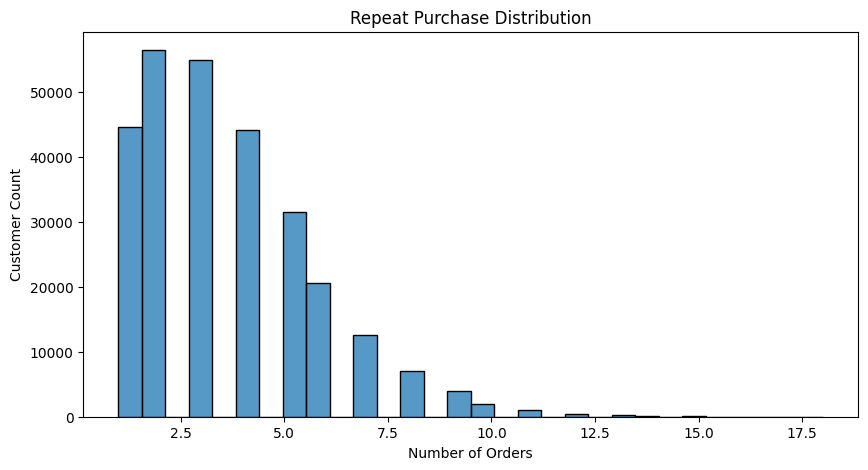

In [7]:

# =========================================================
# STEP 6 — REPEAT PURCHASE ANALYSIS
# =========================================================

repeat_customers = (
    master_df.groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
)

repeat_customers.columns = [
    'customer_unique_id',
    'total_orders'
]

plt.figure(figsize=(10,5))

sns.histplot(
    repeat_customers['total_orders'],
    bins=30
)

plt.title("Repeat Purchase Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Customer Count")

plt.show()

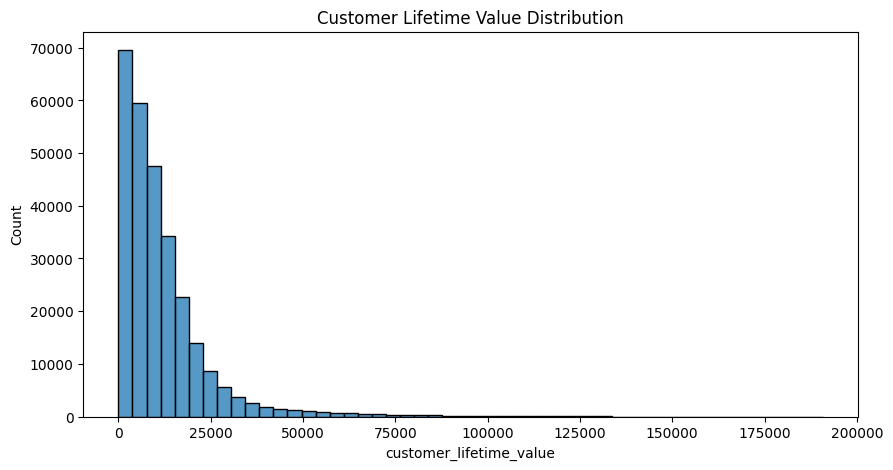

In [8]:
# =========================================================
# STEP 7 — CUSTOMER LIFETIME VALUE (CLV)
# =========================================================

clv_df = (
    master_df.groupby('customer_unique_id')['payment_value']
    .sum()
    .reset_index()
)

clv_df.columns = [
    'customer_unique_id',
    'customer_lifetime_value'
]

plt.figure(figsize=(10,5))

sns.histplot(
    clv_df['customer_lifetime_value'],
    bins=50
)

plt.title("Customer Lifetime Value Distribution")

plt.show()

In [9]:

# =========================================================
# STEP 8 — RFM SEGMENTATION
# =========================================================

snapshot_date = (
    master_df['order_purchase_timestamp'].max()
)

rfm = master_df.groupby('customer_unique_id').agg({
    
    'order_purchase_timestamp': lambda x: (
        snapshot_date - x.max()
    ).days,

    'order_id': 'nunique',

    'payment_value': 'sum'

}).reset_index()

rfm.columns = [
    'customer_unique_id',
    'Recency',
    'Frequency',
    'Monetary'
]

print("\nRFM SAMPLE:\n")

display(rfm.head())


RFM SAMPLE:



,customer_unique_id,Recency,Frequency,Monetary
0,00000ce0-2e08-4b89-ba86-0c8698b2d4fb,247,2,1293.01
1,00004453-ecfa-4c25-94f1-0004cc58286f,599,2,2119.61
2,000062e5-a9a0-4056-a54d-5cf0b2473fda,58,1,10559.70
3,000076de-9d04-4ae8-af41-2f8caf66c899,136,5,35451.16
4,00008df1-f9ce-487d-b5a6-68e6992e025a,54,7,23748.98


In [10]:

# =========================================================
# STEP 9 — COHORT RETENTION ANALYSIS
# =========================================================

master_df['purchase_month'] = (
    master_df['order_purchase_timestamp']
    .dt.to_period('M')
)

cohort_data = (
    master_df.groupby('customer_unique_id')['purchase_month']
    .min()
    .reset_index()
)

cohort_data.columns = [
    'customer_unique_id',
    'cohort_month'
]

print("\nCohort Data Sample:\n")

display(cohort_data.head())


Cohort Data Sample:



,customer_unique_id,cohort_month
0,00000ce0-2e08-4b89-ba86-0c8698b2d4fb,2023-07
1,00004453-ecfa-4c25-94f1-0004cc58286f,2022-04
2,000062e5-a9a0-4056-a54d-5cf0b2473fda,2025-11
3,000076de-9d04-4ae8-af41-2f8caf66c899,2020-08
4,00008df1-f9ce-487d-b5a6-68e6992e025a,2020-08


In [31]:
# =========================================================
# STEP 10 — CUSTOMER SEGMENT ANALYSIS
# =========================================================

segment_analysis = (
    master_df.groupby('customer_segment')
    .agg({
        'payment_value': 'mean',
        'review_score': 'mean',
        'order_id': 'nunique'
    })
)

print("\nCustomer Segment Analysis:\n")

display(segment_analysis)


Customer Segment Analysis:



,payment_value,review_score,order_id
customer_segment,,,
Consumer,1128.040377,4.011157,700676
Corporate,1125.557390,4.010723,199540
VIP,2088.907858,3.850355,99784


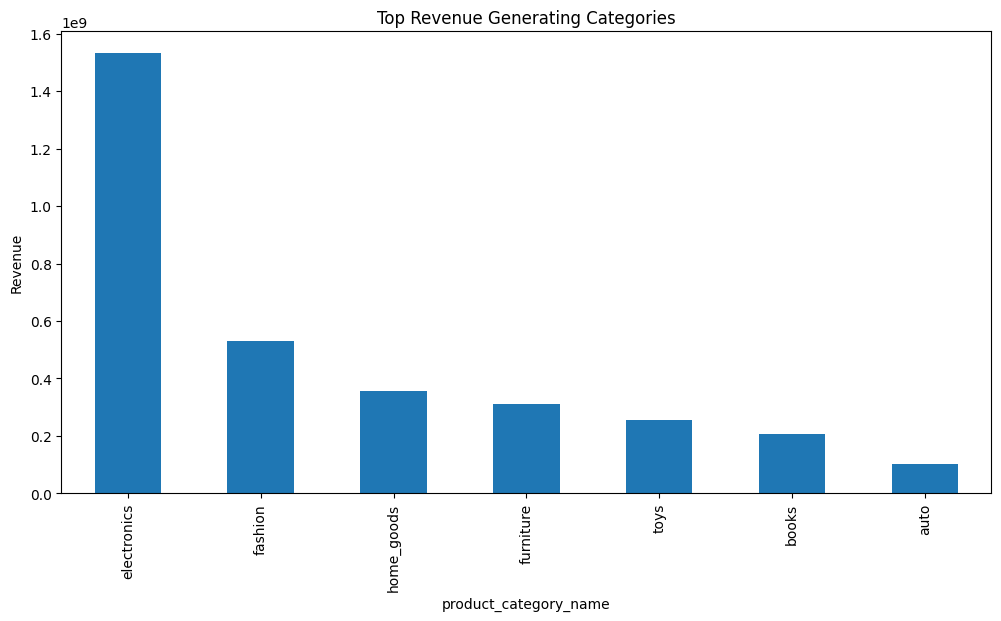

In [12]:
# =========================================================
# STEP 11 — CATEGORY REVENUE ANALYSIS
# =========================================================

category_revenue = (
    master_df.groupby('product_category_name')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

category_revenue.plot(kind='bar')

plt.title("Top Revenue Generating Categories")
plt.ylabel("Revenue")

plt.show()

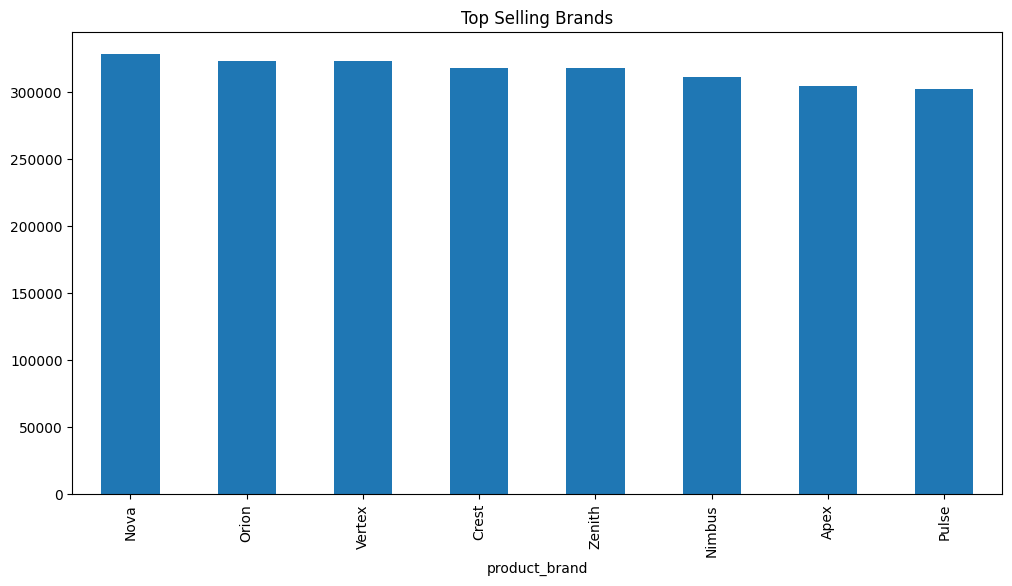

In [13]:
# =========================================================
# STEP 12 — TOP PRODUCTS & BRANDS
# =========================================================

top_brands = (
    master_df.groupby('product_brand')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_brands.plot(kind='bar')

plt.title("Top Selling Brands")

plt.show()

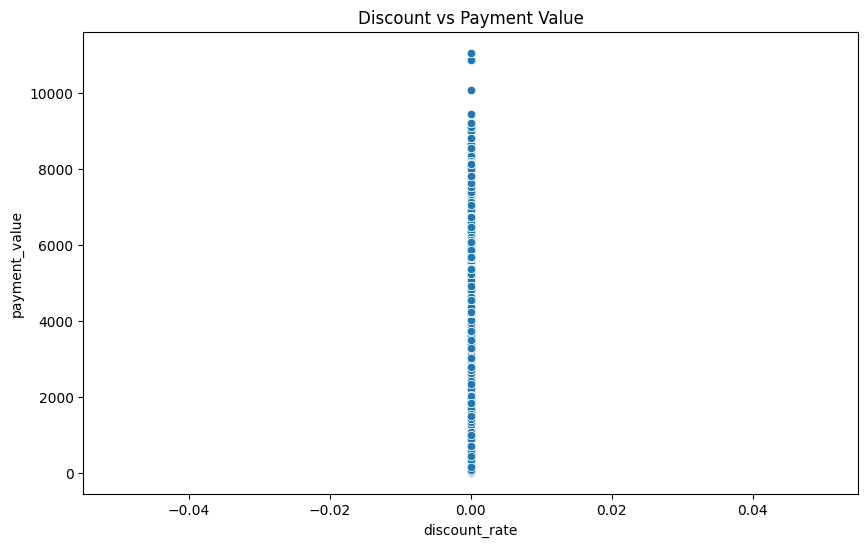

In [14]:
# =========================================================
# STEP 13 — DISCOUNT IMPACT ANALYSIS
# =========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='discount_rate',
    y='payment_value',
    data=master_df
)

plt.title("Discount vs Payment Value")

plt.show()

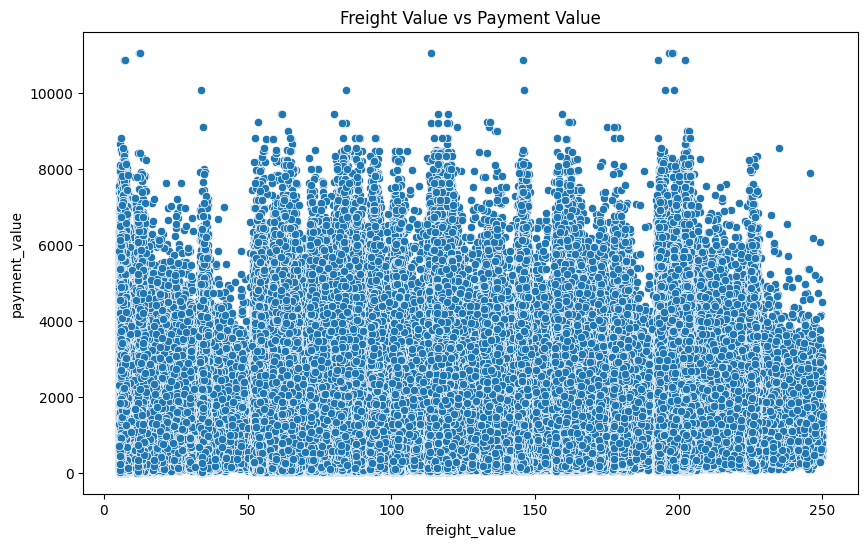

In [15]:
# =========================================================
# STEP 14 — FREIGHT vs CONVERSION ANALYSIS
# =========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='freight_value',
    y='payment_value',
    data=master_df
)

plt.title("Freight Value vs Payment Value")

plt.show()

In [16]:
# =========================================================
# STEP 15 — SELLER PERFORMANCE ANALYSIS
# =========================================================

seller_performance = (
    master_df.groupby('seller_id')
    .agg({
        'payment_value': 'sum',
        'review_score': 'mean',
        'order_id': 'count'
    })
)

seller_performance.columns = [
    'total_revenue',
    'avg_review_score',
    'total_orders'
]

print("\nSeller Performance Sample:\n")

display(seller_performance.head())


Seller Performance Sample:



,total_revenue,avg_review_score,total_orders
seller_id,,,
00a0b558-c880-43f0-bdd2-38b8602d8f87,6384875.82,3.982744,4995
00b55d46-09f6-4826-a3ba-533c2213680b,6843804.27,3.936952,5159
00c15904-9b03-4275-a7fa-66644338021c,6624923.38,3.954631,5070
00c6e54e-1372-4d16-b4ac-94bd27aedbbb,6787597.05,3.960584,5113
0154ca97-7292-407c-8410-5951f615a709,6467930.67,3.958509,5110


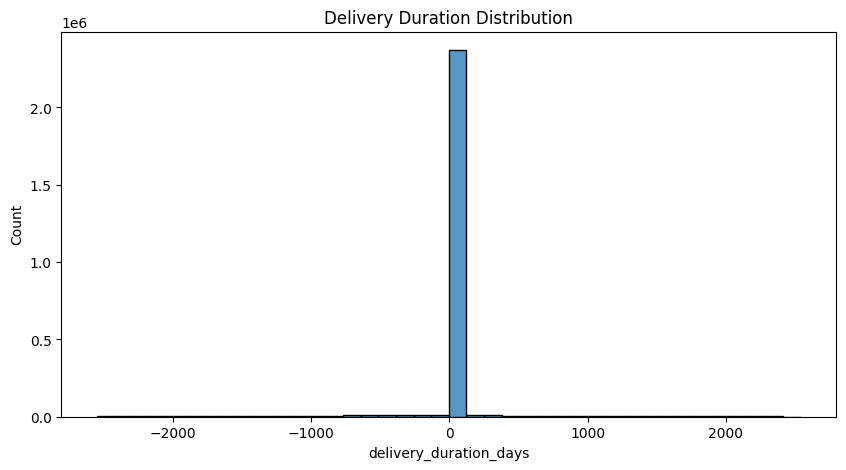

In [17]:
# =========================================================
# STEP 16 — DELAYED DELIVERY ANALYSIS
# =========================================================

master_df['delivery_duration_days'] = (
    pd.to_datetime(master_df['order_delivered_customer_date'])
    - pd.to_datetime(master_df['order_purchase_timestamp'])
).dt.days

plt.figure(figsize=(10,5))

sns.histplot(
    master_df['delivery_duration_days'],
    bins=40
)

plt.title("Delivery Duration Distribution")

plt.show()

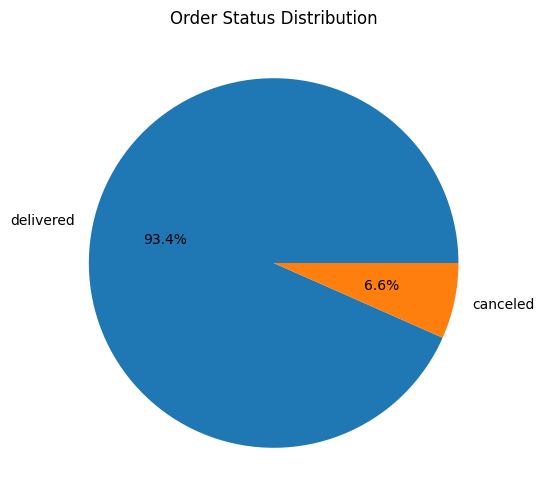

In [18]:
# =========================================================
# STEP 17 — CANCELLATION ANALYSIS
# =========================================================

cancel_analysis = (
    master_df['order_status']
    .value_counts()
)

plt.figure(figsize=(6,6))

cancel_analysis.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Order Status Distribution")

plt.ylabel("")

plt.show()

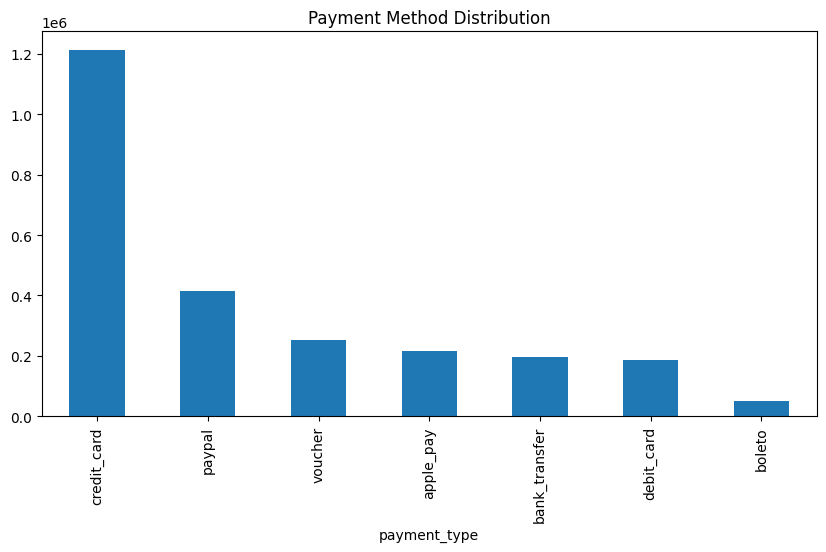

In [19]:
# =========================================================
# STEP 18 — PAYMENT BEHAVIOR ANALYSIS
# =========================================================

payment_analysis = (
    master_df['payment_type']
    .value_counts()
)

plt.figure(figsize=(10,5))

payment_analysis.plot(kind='bar')

plt.title("Payment Method Distribution")

plt.show()

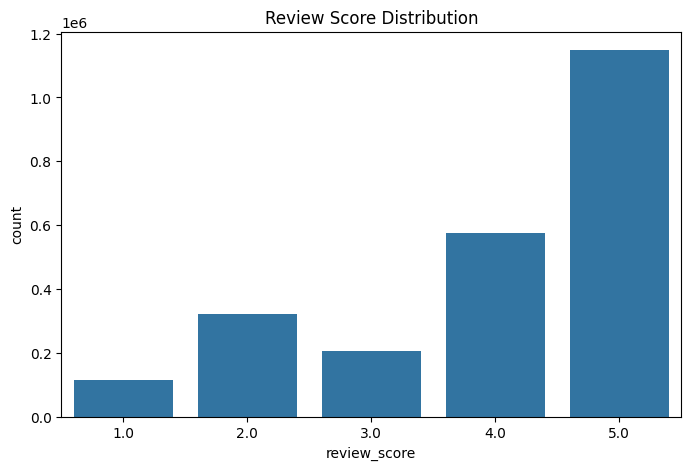

In [20]:
# =========================================================
# STEP 19 — REVIEW SCORE ANALYSIS
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='review_score',
    data=master_df
)

plt.title("Review Score Distribution")

plt.show()

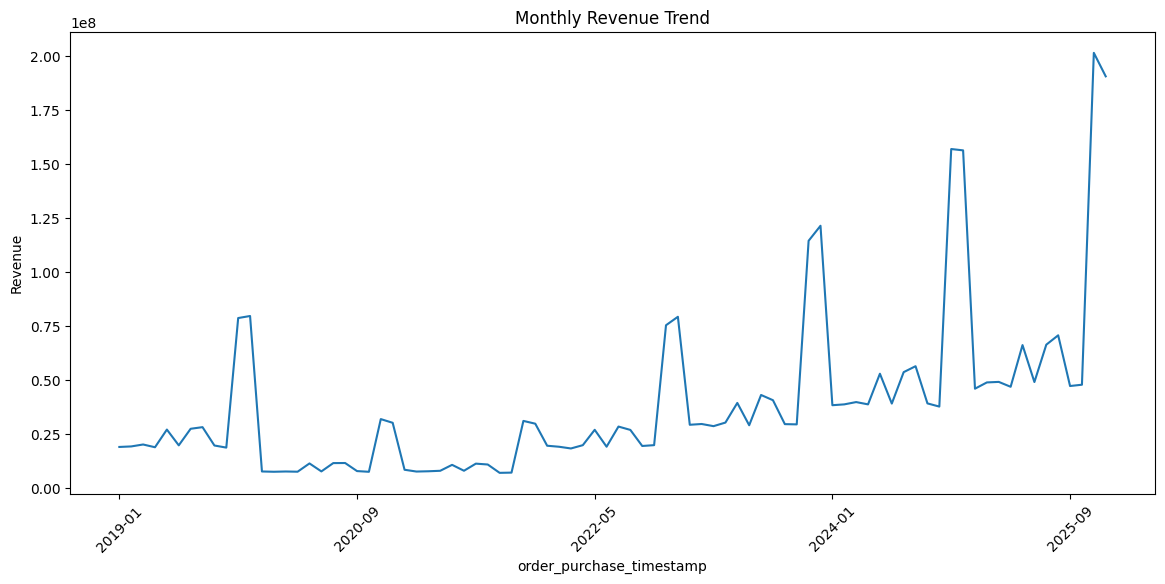

In [21]:
# =========================================================
# STEP 20 — MONTHLY SALES TREND
# =========================================================

monthly_sales = (
    master_df.groupby(
        master_df['order_purchase_timestamp'].dt.to_period('M')
    )['payment_value']
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

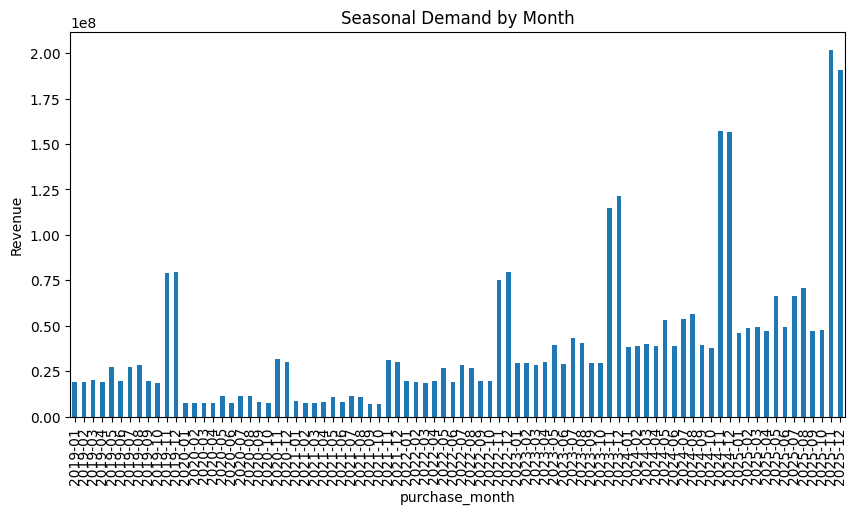

In [22]:
# =========================================================
# STEP 21 — SEASONAL DEMAND ANALYSIS
# =========================================================

seasonal_demand = (
    master_df.groupby('purchase_month')['payment_value']
    .sum()
)

plt.figure(figsize=(10,5))

seasonal_demand.plot(kind='bar')

plt.title("Seasonal Demand by Month")

plt.ylabel("Revenue")

plt.show()

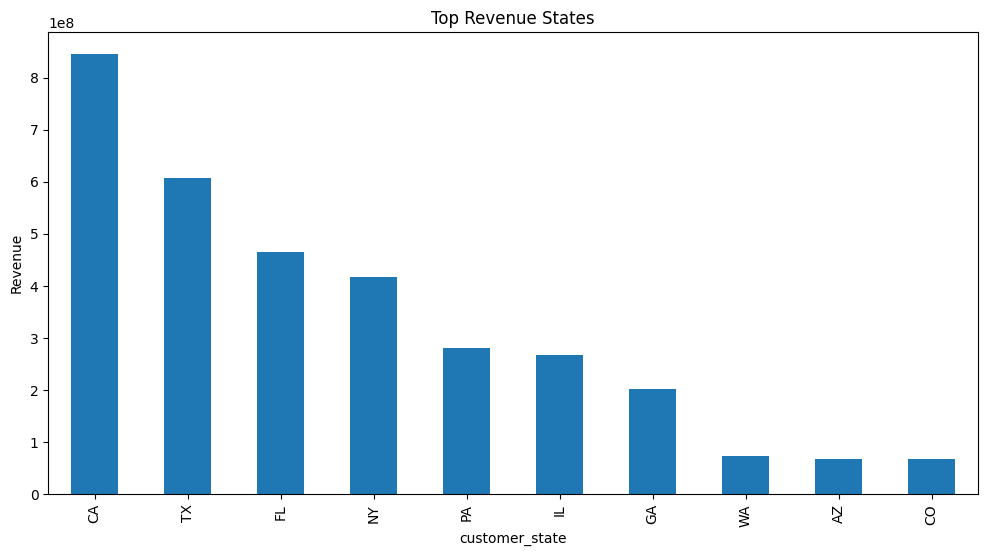

In [23]:
# =========================================================
# STEP 22 — REGION-WISE DEMAND ANALYSIS
# =========================================================

region_demand = (
    master_df.groupby('customer_state')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

region_demand.plot(kind='bar')

plt.title("Top Revenue States")

plt.ylabel("Revenue")

plt.show()

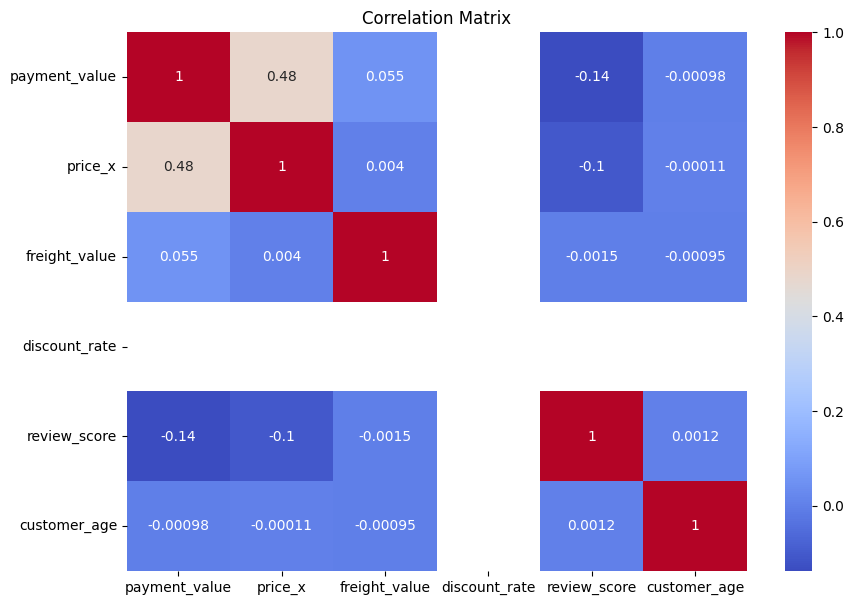

In [30]:
# =========================================================
# STEP 23 — CORRELATION ANALYSIS
# =========================================================

numerical_cols = [
    'payment_value',
    'price_x',
    'freight_value',
    'discount_rate',
    'review_score',
    'customer_age'
]

corr_matrix = (
    master_df[numerical_cols]
    .corr()
)

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [27]:
# =========================================================
# STEP 24 — STATISTICAL SUMMARY
# =========================================================

print("\n================ STATISTICAL SUMMARY ================\n")

display(master_df.describe())


================ STATISTICAL SUMMARY ================



,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration_days,delivery_delay_days,approval_time_hours,purchase_year,customer_age,customer_zip_code_prefix,order_item_id,price_x,freight_value,discount_rate,product_weight_g,product_length_cm,product_height_cm,product_width_cm,cost,price_y,seller_contact_age,seller_zip_code_prefix,payment_sequential,payment_installments,payment_value,review_score,review_creation_date,review_answer_timestamp
count,2530433,2530433,2530430,2530430,2530433,2.530430e+06,2.530430e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2530433.0,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.530433e+06,2.362704e+06,2362704,2362704
mean,2023-07-31 03:09:12.729490688,2023-07-31 08:14:00.473517568,2023-07-21 17:08:26.007727104,2023-07-28 06:26:19.350993664,2023-08-09 05:14:27.383537152,-3.091184e+00,-1.198215e+01,5.079929e+00,2.022997e+03,3.538041e+01,5.727191e+04,1.848657e+00,4.419811e+02,1.087241e+02,0.0,4.185640e+03,4.172139e+01,1.655438e+01,1.669827e+01,3.326933e+02,4.497627e+02,3.594256e+01,5.881347e+04,1.130655e+00,4.151308e+00,1.302061e+03,3.981864e+00,2023-08-01 10:16:52.022502144,2023-08-01 12:16:52.022503936
min,2019-01-01 01:21:03,2019-01-01 03:20:54,2019-01-02 03:20:54,2019-01-04 07:29:50,2019-01-06 07:29:50,-2.551000e+03,-2.559000e+03,1.666667e-01,2.019000e+03,1.800000e+01,1.001000e+04,1.000000e+00,1.001000e+01,5.060000e+00,0.0,1.000000e+02,5.000000e+00,5.000000e+00,5.000000e+00,4.430000e+00,1.001000e+01,1.800000e+01,1.001100e+04,1.000000e+00,1.000000e+00,1.555000e+01,1.000000e+00,2019-01-05 18:51:36,2019-01-05 20:51:36
25%,2022-07-03 19:52:04,2022-07-04 01:04:42,2022-06-23 22:41:05,2022-06-30 13:43:45.750000128,2022-07-13 02:57:50,5.000000e+00,-2.000000e+00,2.616667e+00,2.022000e+03,2.700000e+01,3.036800e+04,1.000000e+00,6.429000e+01,6.466000e+01,0.0,5.850000e+02,2.000000e+01,1.000000e+01,1.100000e+01,2.817000e+01,6.505000e+01,2.700000e+01,3.039600e+04,1.000000e+00,1.000000e+00,4.771500e+02,3.000000e+00,2022-07-04 18:10:05,2022-07-04 20:10:05
50%,2024-01-26 14:49:13,2024-01-26 19:59:56,2024-01-14 21:20:17,2024-01-21 05:32:10,2024-02-04 13:55:32,7.000000e+00,-2.000000e+00,5.083333e+00,2.024000e+03,3.500000e+01,7.701200e+04,2.000000e+00,1.765900e+02,1.060100e+02,0.0,1.096000e+03,3.200000e+01,1.600000e+01,1.600000e+01,8.370000e+01,1.848300e+02,3.600000e+01,7.701600e+04,1.000000e+00,2.000000e+00,9.882200e+02,4.000000e+00,2024-01-25 04:47:58,2024-01-25 06:47:58
75%,2025-03-02 05:55:15,2025-03-02 09:33:56,2025-02-17 11:30:34.500000,2025-02-23 23:19:10.249999872,2025-03-11 02:25:52,8.000000e+00,-2.000000e+00,7.533333e+00,2.025000e+03,4.300000e+01,9.001900e+04,2.000000e+00,7.365900e+02,1.594500e+02,0.0,3.590000e+03,4.800000e+01,2.300000e+01,2.300000e+01,5.076700e+02,7.365900e+02,4.400000e+01,9.003100e+04,1.000000e+00,7.000000e+00,1.872050e+03,5.000000e+00,2025-02-28 04:33:58,2025-02-28 06:33:58
max,2025-12-31 23:59:31,2026-01-01 09:38:05,2025-12-29 23:56:55,2025-12-31 23:59:35,2026-01-20 02:22:01,2.543000e+03,2.535000e+03,1.000000e+01,2.025000e+03,7.000000e+01,9.819900e+04,6.000000e+00,1.745340e+03,2.502900e+02,0.0,4.986900e+04,1.990000e+02,2.900000e+01,2.900000e+01,1.693120e+03,1.999850e+03,7.000000e+01,9.819800e+04,2.000000e+00,1.200000e+01,1.105452e+04,5.000000e+00,2026-01-07 23:45:12,2026-01-08 01:45:12
std,NaN,NaN,NaN,NaN,NaN,2.701278e+02,2.701487e+02,2.843281e+00,1.971267e+00,1.122896e+01,3.063201e+04,9.724188e-01,5.266148e+02,6.385504e+01,0.0,8.433037e+03,3.541551e+01,7.326846e+00,7.085859e+00,4.517174e+02,5.385349e+02,1.136211e+01,3.193367e+04,3.370228e-01,3.774100e+00,1.077733e+03,1.246870e+00,NaN,NaN


In [29]:
# =========================================================
# STEP 25 — BUSINESS INSIGHTS
# =========================================================

print("\n===================================================")
print("KEY BUSINESS INSIGHTS")
print("===================================================")

print("""
1. Identified high-value customer segments using CLV.

2. Analyzed repeat purchase behavior and retention patterns.

3. Detected top-performing product categories and brands.

4. Evaluated seller performance using revenue and review scores.

5. Analyzed impact of discounts on customer spending.

6. Studied freight cost impact on conversions.

7. Identified delivery duration patterns and operational bottlenecks.

8. Evaluated customer review distributions and satisfaction.

9. Analyzed seasonal demand and monthly revenue trends.

10. Identified dominant payment methods and customer behavior.
""")


KEY BUSINESS INSIGHTS

1. Identified high-value customer segments using CLV.

2. Analyzed repeat purchase behavior and retention patterns.

3. Detected top-performing product categories and brands.

4. Evaluated seller performance using revenue and review scores.

5. Analyzed impact of discounts on customer spending.

6. Studied freight cost impact on conversions.

7. Identified delivery duration patterns and operational bottlenecks.

8. Evaluated customer review distributions and satisfaction.

9. Analyzed seasonal demand and monthly revenue trends.

10. Identified dominant payment methods and customer behavior.



In [26]:
# =========================================================
# STEP 26 — NOTEBOOK COMPLETION
# =========================================================

print("\n===================================================")
print("03_eda.ipynb COMPLETED SUCCESSFULLY")
print("===================================================")


03_eda.ipynb COMPLETED SUCCESSFULLY
